## Import packages and utility functions  

All functions are included in `utils.py`

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d, griddata
import matplotlib.pyplot as plt
import glob
import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import time
import gsw
from datetime import datetime
import geopandas as gpd
from matplotlib.dates import DateFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
from pathlib import Path
import json

import cartopy
import cartopy.crs as ccrs

# custom functions 
from utilities import *

## (1) Plot sections

Function for making sections for select variables and cruises 

In [2]:
# -----------------------------
# extract coastline coordinates (only once)
# -----------------------------

# set bounding box, format:
# region = [lon_min, lon_max, lat_min, lat_max]
region = [-3, 2, 2, 7]

# extract lat, lon
coast_lon, coast_lat = coastline_points(region, scale="10m")


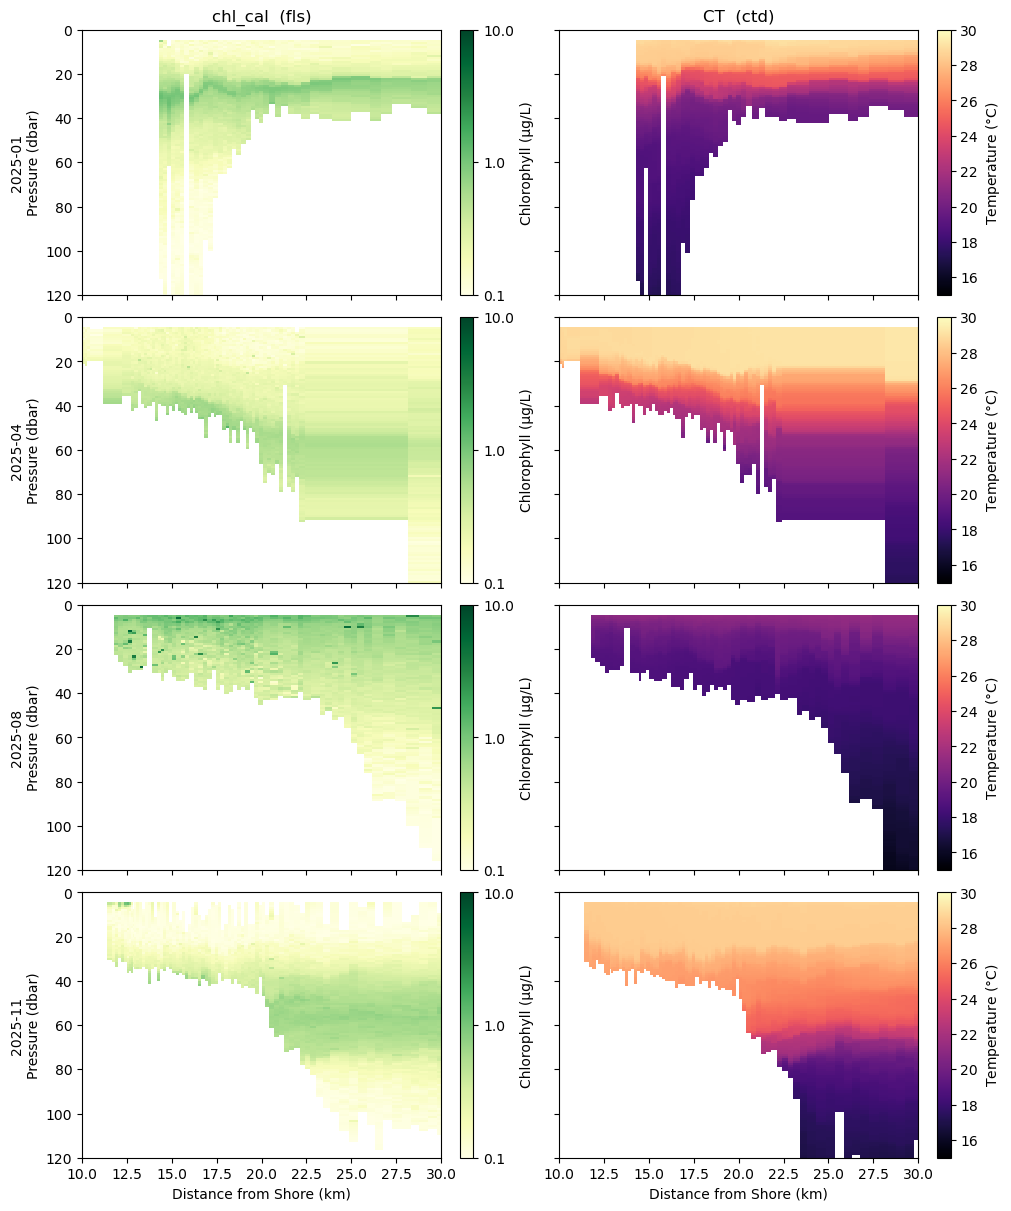

In [3]:
cruises = ['2025-01', '2025-04', '2025-08', '2025-11']
variables = ["chl_cal", "CT"]

fig, axs = plot_sections_grid(
    cruises=cruises,
    transect_name="sakumono",
    variables=variables,
    metadata_path="./variable_metadata.json",
    shared_xlim=(10, 30),
    depth_limit=120,
    include_topo=False,
    extrapolate=False,
    use_density_contours=False,
    coast_lon=coast_lon,
    coast_lat=coast_lat,
)

plt.show()

## (2) Plot profiles

Function for plotting average profile

In [3]:
def plot_profiles(datasets, show_mean=True):
    max_depth = 150
    depth_grid = np.linspace(10, max_depth, 50)

    # Prepare arrays for interpolation
    CT_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    SA_interp = np.full((len(datasets), len(depth_grid)), np.nan)
    sigma_interp = np.full((len(datasets), len(depth_grid)), np.nan)

    for i, ds in enumerate(datasets):
        p = ds["P"].values
        ct = ds["CT"].values
        sa = ds["SA"].values
        
        # Interpolate missing values
        p = interpolate_nans(p, np.arange(len(p)))
        ct = interpolate_nans(ct, np.arange(len(ct)))
        sa = interpolate_nans(sa, np.arange(len(sa)))
        
        # Interpolate to the common depth grid
        CT_interp[i, :] = np.interp(depth_grid, p, ct, left=np.nan, right=np.nan)
        SA_interp[i, :] = np.interp(depth_grid, p, sa, left=np.nan, right=np.nan)
        sigma_interp[i, :] = gsw.density.sigma0(SA_interp[i, :], CT_interp[i, :])

    # Compute mean and std
    CT_mean = np.nanmean(CT_interp, axis=0)
    CT_std  = np.nanstd(CT_interp, axis=0)

    SA_mean = np.nanmean(SA_interp, axis=0)
    SA_std  = np.nanstd(SA_interp, axis=0)

    sigma_mean = np.nanmean(sigma_interp, axis=0)
    sigma_std  = np.nanstd(sigma_interp, axis=0)

    # Plotting
    fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

    if show_mean:
        axs[0].plot(CT_mean, depth_grid, label='CT mean', color='tab:blue')
        axs[0].fill_betweenx(depth_grid, CT_mean - CT_std, CT_mean + CT_std, color='tab:blue', alpha=0.3)
        
        axs[1].plot(SA_mean, depth_grid, label='SA mean', color='tab:green')
        axs[1].fill_betweenx(depth_grid, SA_mean - SA_std, SA_mean + SA_std, color='tab:green', alpha=0.3)

        axs[2].plot(sigma_mean, depth_grid, label='Sigma0 mean', color='tab:red')
        axs[2].fill_betweenx(depth_grid, sigma_mean - sigma_std, sigma_mean + sigma_std, color='tab:red', alpha=0.3)
    else:
        for i in range(len(datasets)):
            axs[0].plot(CT_interp[i, :], depth_grid, color='tab:blue', alpha=0.5)
            axs[1].plot(SA_interp[i, :], depth_grid, color='tab:green', alpha=0.5)
            axs[2].plot(sigma_interp[i, :], depth_grid, color='tab:red', alpha=0.5)

    for ax, title in zip(axs, ['Conservative Temperature (°C)', 'Absolute Salinity (g/kg)', 'Sigma₀ (kg/m³)']):
        ax.invert_yaxis()
        ax.set_xlabel(title)
        ax.grid(True)

    axs[0].set_ylabel('Depth (m)')
    plt.tight_layout()
    plt.show()

## (3) Plot T-S diagram

Function for making T-S diagrams